<a href="https://colab.research.google.com/github/AxisAngeles/Smart_Data_DS_AI/blob/main/LSTM_Urban_planning_application.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#########################################################################
###########------- Smart Data Consulting  ------------###################
#########################################################################
# Capacitador: Julio César Bernal Fernández
# email: juliobf08@gmail.com
# Tema : Series de Tiempo - LSTM
# version: 1.0
#########################################################################

In [2]:
!python -m pip install statsmodels

In [3]:
!statsmodels --version

/bin/bash: line 1: statsmodels: command not found


In [4]:
!pip install --upgrade statsmodels

In [6]:
# Nos vinculamos a nuestro drive, para poder usar facilmente GColab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Parte 1 - Importamos las librerias necesarias.

# Importación de las librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Parte 2 - Tratamiento de datos y generacion de los datasets.

In [ ]:
# Notas:
# parse_dates: Especifica la columna que contiene la información de fecha y hora.
# index_col:   El índice debe ser la variable que representa la información de fecha y hora.
# date_parser: Especifica una función que convierte una cadena de entrada en variable de fecha y hora. Por defecto, Pandas lee los datos en formato "AAAA-MM-DD HH: MM: SS".
# Si los datos no están en este formato, el formato debe definirse manualmente.

In [8]:
# Importamos el set de datos!
file = 'https://raw.githubusercontent.com/AxisAngeles/Smart_Data_DS_AI/main/Aplicacion_UrbanismoTransportePublico.csv'
df = pd.read_csv(file,
                parse_dates=['Fecha'],
                dayfirst=True,
                index_col='Fecha')
df

,Trafico
Fecha,
2012-08-25,76
2012-08-26,88
2012-08-27,62
2012-08-28,58
2012-08-29,60
...,...
2014-09-21,9102
2014-09-22,14116
2014-09-23,13304


In [9]:
# Revisamos la cantidad de elementos del dataset!
df.shape

(762, 1)

In [10]:
# Vemos un poco la estructura de datos!
df.head(10)

,Trafico
Fecha,
2012-08-25,76
2012-08-26,88
2012-08-27,62
2012-08-28,58
2012-08-29,60
2012-08-30,74
2012-08-31,78
2012-09-01,112
2012-09-02,118


In [11]:
# En caso de ser necesario ordenamos los registros por fecha.
df.sort_values('Fecha', inplace=True, ascending=True)

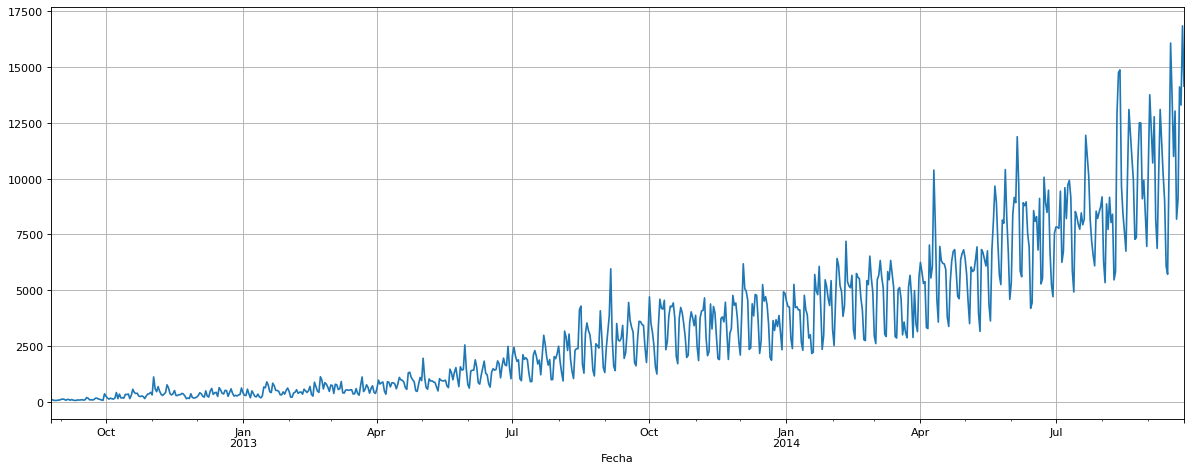

In [12]:
# Visualizamos la informacion del conjunto de datos!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
df['Trafico'].plot()
plt.tight_layout()
plt.grid()
plt.show()

# Conclusiones:
# Zt = T + e + C + a
# Tendencia deterministica de tipo lineal creciente!
# Estacionalidad muy marcada!

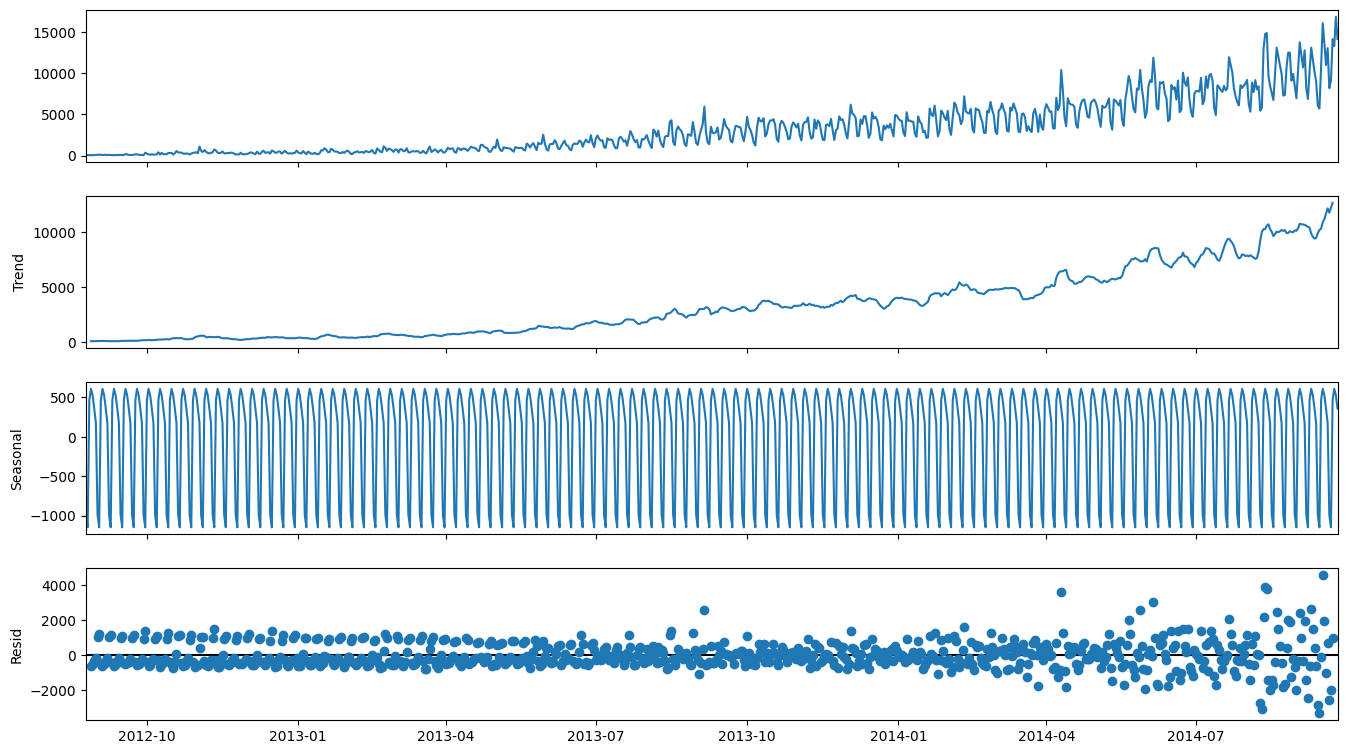

In [14]:
# Descomposición de la serie de tiempo

import statsmodels.api as sm
import matplotlib.pyplot as plt

res = sm.tsa.seasonal_decompose(df)
fig = res.plot()
fig.set_figheight(8)
fig.set_figwidth(15)
plt.show()

In [ ]:
# Deep Learning --> Machine Learning!

In [15]:
# Machine Learning , X  -->  y
# Train - Test

# En series de tiempo generalmente se hace un particion distinta!
# Seamos cuidadosos y no es igual al train test split!
train, test = df.iloc[0:-100], df.iloc[-100:len(df)]
print(len(train), len(test))


662 100


In [16]:
test.head(5)

,Trafico
Fecha,
2014-06-18,8300
2014-06-19,6802
2014-06-20,9118
2014-06-21,5282
2014-06-22,5540


In [17]:
# Importante!
# En series de tiempo es necesario escalar las variable o caracteristicas!
# Para escalar puedes usar normalización,estandarización u otro tipo de escalado.
train_max = train.max()
train_min = train.min()

In [18]:
train_min

,0
Trafico,58


In [19]:
# Normalizamos los set de datos, train y test!
# Pueden utilizar la metodologia de escalamiento que deseen!
train_set_scaled = (train - train_min)/(train_max - train_min)
test_set_scaled = (test - train_min)/(train_max - train_min)

In [20]:
# Revisamos el escalado!
train_set_scaled.head(10)

,Trafico
Fecha,
2012-08-25,0.001522
2012-08-26,0.002536
2012-08-27,0.000338
2012-08-28,0.000000
2012-08-29,0.000169
2012-08-30,0.001353
2012-08-31,0.001691
2012-09-01,0.004565
2012-09-02,0.005073


In [21]:
train_set_scaled.shape

(662, 1)

In [22]:
# Definimos la funcion de la arquitectura X - y.
def create_dataset(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [23]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 1 # Comencemos un vector unitario

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [24]:
# reshape input debe ser 3D para las LSTM's: [samples, timesteps, features]
X_train.shape

(661, 1, 1)

In [25]:
X_train[653],X_train[654]

(array([[0.74940818]]), array([[0.73841731]]))

In [26]:
y_train[653]

np.float64(0.7384173148461278)

In [27]:
# Parte 3 - Creamos la arquitecura de Red Neuronal Recurrente!

In [28]:
X_train.shape[2]

1

In [29]:
# Importando de keras las librerias mas importantes!
from keras.models import Sequential # Arquitectura de red neuronal!
from keras.layers import Dense      # Capa densa!
from keras.layers import LSTM       # Capa recurrente
from keras.layers import Dropout    # Evita el overfitting (Inactiva algunas neuronas)

def lstm_architecture(X_data,rate_dropout):
    # Inicializando the RNN
    model = Sequential()

    # 1ra capa LSTM y Dropout para regularización.
    # input_shape (amplitude,1)
    model.add(LSTM(units = 250, return_sequences = True, input_shape=(X_data.shape[1], X_data.shape[2])))
    # 20% de las neuronas serán ignoradas durante el training (20%xNodos = 10)
    # Para hacer menos probable el overfiting
    model.add(Dropout(rate=rate_dropout))

    # 2da capa LSTM y Dropout para regularización.
    model.add(LSTM(units = 250, return_sequences = True))
    model.add(Dropout(rate=rate_dropout))

    # 3ra capa LSTM y Dropout para regularización.
    model.add(LSTM(units = 250, return_sequences = True))
    model.add(Dropout(rate=rate_dropout))

    # 4ta capa LSTM y Dropout para regularización.
    model.add(LSTM(units = 250, return_sequences = False))
    model.add(Dropout(rate=rate_dropout))

    # Capa de Salida!
    model.add(Dense(units = 1))

    # Resumen del modelo!
    model.summary()

    return model

In [30]:
import datetime
print('Iniciando a las: ', datetime.datetime.now())
print("...")

# Compiling the RNN
model_1 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_1.compile(optimizer = 'adam', loss = 'mean_squared_error')

Iniciando a las:  2026-04-10 02:48:55.491150
...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 1, 250)         │       252,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 1, 250)         │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 1, 250)         │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 250)            │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,755,251 (6.70 MB)

 Trainable params: 1,755,251 (6.70 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# Ejecutamos la RNN!

history = model_1.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - loss: 0.0274
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0625
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0331
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0254
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0171
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0190
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0203
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0084
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0080
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0134
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0127
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0189
Epoch 13/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0165
Epoch 14/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0184
Epoch 15/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - lo

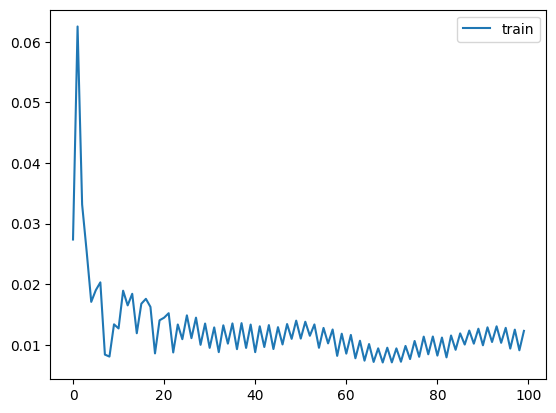

In [32]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

In [33]:
# Predecimos sobre la data de test!
y_pred = model_1.predict(X_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step


In [34]:
# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

/tmp/ipykernel_1900/2894951188.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
/tmp/ipykernel_1900/2894951188.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
/tmp/ipykernel_1900/2894951188.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

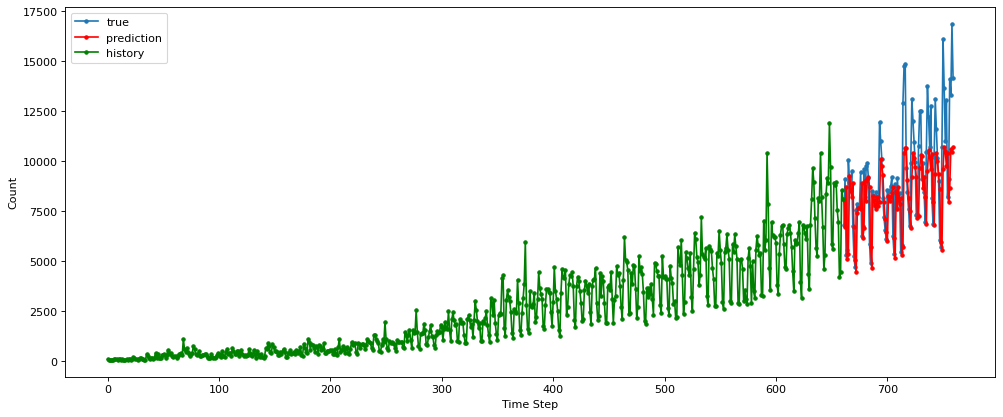

In [35]:
# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()

In [36]:
# Vemos algunos indicadores del ajuste!
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: ',rmse)

# Definimos y calculamos el MAPE (mean_absolute_percentage_error)
y_test, y_pred = np.array(y_test), np.array(y_pred)
print(f'MAPE: ',np.mean(np.abs((y_test - y_pred) / y_test)) * 100)


RMSE:  2440.228428666032
MAPE:  27.20510635893344


In [ ]:
# Tarea:
# Con el objetivo de ser mas preciso con la red neuronal, probar:
# 1) Aumentar el numero de capas ocultas.
# 2) Ir variando el numero de neuronas por capa oculta.
# 3) el dropout midificarlo, dejar inactivas el 20% de las neuronas por capa es demasiado.
# 4) El numero de epoch es poco para entrenar y parametrizar 2 MM de parametros.
# 5) Probar entre 40 y 64 el bach size.

In [37]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 7 # Porque tengo data diaria y necesito estacionalidad de la semana!

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [38]:
model_2 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_2.compile(optimizer = 'adam', loss = 'mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 7, 250)         │       252,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 7, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 7, 250)         │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 7, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 7, 250)         │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 7, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 250)            │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,755,251 (6.70 MB)

 Trainable params: 1,755,251 (6.70 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
# Ejecutamos la RNN!

history = model_2.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0082
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0676
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0474
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0365
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0135
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0079
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0082
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0065
Epoch 9/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0079
Epoch 10/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0086
Epoch 11/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0169
Epoch 12/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0117
Epoch 13/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0195
Epoch 14/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0200
Epoch 15/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - lo

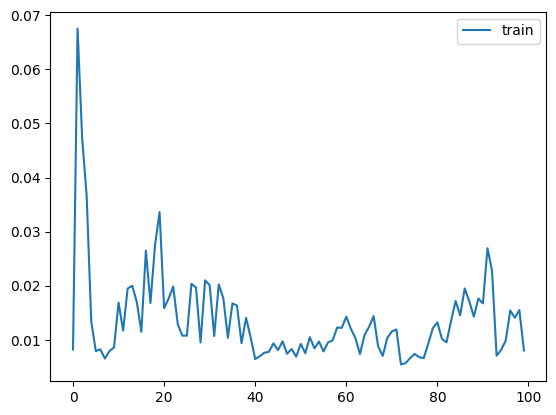

In [40]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 169ms/step


/tmp/ipykernel_1900/1046102612.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
/tmp/ipykernel_1900/1046102612.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
/tmp/ipykernel_1900/1046102612.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

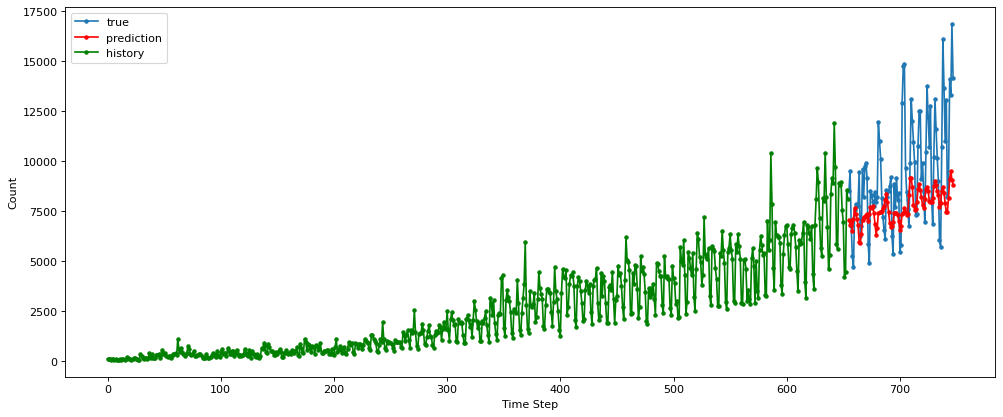

In [41]:
# Predecimos sobre la data de test!
y_pred = model_2.predict(X_test)

# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()

In [42]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: ',rmse)

# Definimos y calculamos el MAPE (mean_absolute_percentage_error)
y_test, y_pred = np.array(y_test), np.array(y_pred)
print(f'MAPE: ',np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

RMSE:  2821.7139478193626
MAPE:  23.977202710519226


## Probando distintos hiperparámetros

In [43]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 30 # Porque tengo data diaria y necesito estacionalidad de la semana!

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [44]:
model_3 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_3.compile(optimizer = 'adam', loss = 'mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 30, 250)        │       252,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 30, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_9 (LSTM)                   │ (None, 30, 250)        │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_10 (LSTM)                  │ (None, 30, 250)        │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 30, 250)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_11 (LSTM)                  │ (None, 250)            │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,755,251 (6.70 MB)

 Trainable params: 1,755,251 (6.70 MB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Ejecutamos la RNN!

history = model_3.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/step - loss: 0.0101
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0202
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0350
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0208
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0236
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0438
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0210
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0196
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0332
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0176
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0079
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0112
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0122
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0148
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - lo

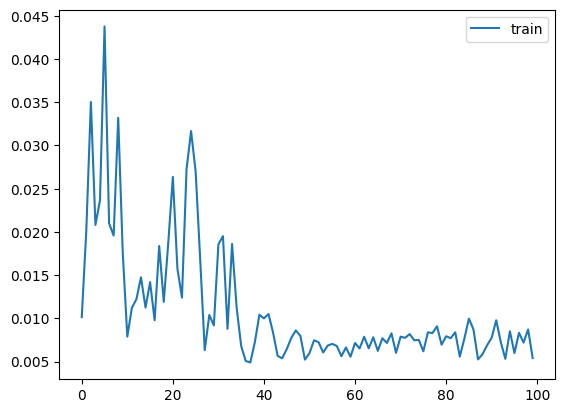

In [46]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 261ms/step


/tmp/ipykernel_1900/3374722979.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
/tmp/ipykernel_1900/3374722979.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
/tmp/ipykernel_1900/3374722979.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

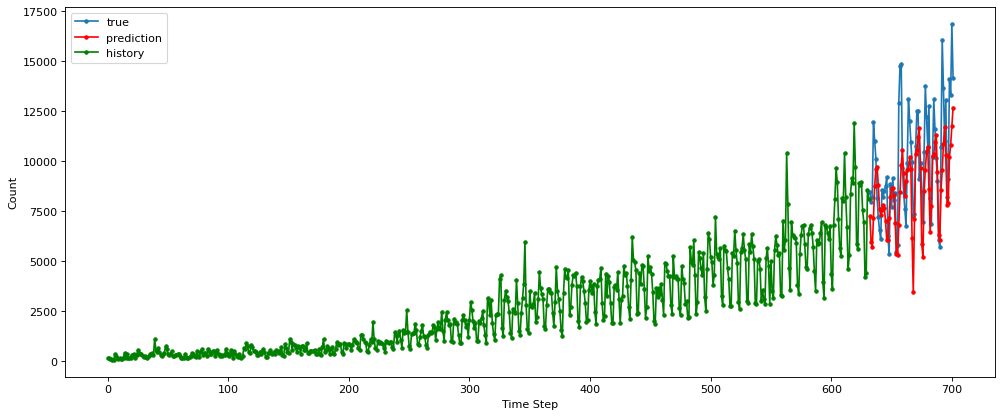

In [47]:
# Predecimos sobre la data de test!
y_pred = model_3.predict(X_test)

# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()

In [48]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f'RMSE: ',rmse)

# Definimos y calculamos el MAPE (mean_absolute_percentage_error)
y_test, y_pred = np.array(y_test), np.array(y_pred)
print(f'MAPE: ',np.mean(np.abs((y_test - y_pred) / y_test)) * 100)

RMSE:  2443.06408247049
MAPE:  28.485738237404313


## Feature Engineering

In [50]:
# Importamos el set de datos!
df = pd.read_csv(file,
                   parse_dates=['Fecha'],
                   index_col='Fecha')
df

/tmp/ipykernel_1900/3754127496.py:2: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df = pd.read_csv(file,


,Trafico
Fecha,
2012-08-25,76
2012-08-26,88
2012-08-27,62
2012-08-28,58
2012-08-29,60
...,...
2014-09-21,9102
2014-09-22,14116
2014-09-23,13304


In [51]:
df.sort_values('Fecha', inplace=True, ascending=True)

In [52]:
ma_day = [7, 30]

for ma in ma_day:
    column_name = f"MA({ma})"
    df[column_name] = df['Trafico'].rolling(ma).mean()
    #test_set_scaled[column_name] = test_set_scaled['Trafico'].rolling(ma).mean()

In [53]:
df = df.dropna()

In [54]:
# Hacemos la partición de la data en training y test para una serie de tiempo
train, test = df.iloc[0:-100], df.iloc[-100:len(df)]
print(len(train), len(test))

633 100


In [55]:
train.head(10)

,Trafico,MA(7),MA(30)
Fecha,,,
2012-09-23,102,113.142857,88.533333
2012-09-24,162,123.142857,91.400000
2012-09-25,160,119.142857,93.800000
2012-09-26,118,113.428571,95.666667
2012-09-27,104,116.285714,97.200000
2012-09-28,78,114.571429,97.800000
2012-09-29,62,112.285714,97.400000
2012-09-30,356,148.571429,106.666667
2012-10-01,248,160.857143,111.200000


In [56]:
#Escalamos nuestro dataset
train_min = train.min()
train_max = train.max()

train_min,train_max

(Trafico     62.000000
 MA(7)      112.285714
 MA(30)      88.533333
 dtype: float64,
 Trafico    11886.000000
 MA(7)       8583.714286
 MA(30)      7632.533333
 dtype: float64)

In [57]:
train_set_scaled = (train - train_min)/(train_max - train_min)
test_set_scaled = (test - train_min)/(train_max - train_min)

#Revisamos el escalado
train_set_scaled.head(10)

,Trafico,MA(7),MA(30)
Fecha,,,
2012-09-23,0.003383,0.000101,0.000000
2012-09-24,0.008457,0.001282,0.000380
2012-09-25,0.008288,0.000809,0.000698
2012-09-26,0.004736,0.000135,0.000946
2012-09-27,0.003552,0.000472,0.001149
2012-09-28,0.001353,0.000270,0.001228
2012-09-29,0.000000,0.000000,0.001175
2012-09-30,0.024865,0.004283,0.002404
2012-10-01,0.015731,0.005734,0.003005


In [58]:
# Definimos la funcion de la arquitectura X - y.
def create_dataset_multivariable(X, y, time_steps=1):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        v = X.iloc[i:(i + time_steps)].values
        Xs.append(v)
        ys.append(y.iloc[i + time_steps])
    return np.array(Xs), np.array(ys)

In [59]:
# Definimos un time_step y procedemos a crear los dataframes!
time_steps = 7 # Porque tengo data diaria y necesito estacionalidad de la semana!

X_train, y_train = create_dataset(train_set_scaled, train_set_scaled.Trafico , time_steps)
X_test,  y_test  = create_dataset(test_set_scaled,  test_set_scaled.Trafico, time_steps)

In [60]:
X_train.shape

(626, 7, 3)

In [61]:
model_6 = lstm_architecture(X_data=X_train,rate_dropout=0.2)
model_6.compile(optimizer = 'adam', loss = 'mean_squared_error')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_12 (LSTM)                  │ (None, 7, 250)         │       254,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 7, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_13 (LSTM)                  │ (None, 7, 250)         │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_14 (LSTM)                  │ (None, 7, 250)         │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 7, 250)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_15 (LSTM)                  │ (None, 250)            │       501,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 250)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           251 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,757,251 (6.70 MB)

 Trainable params: 1,757,251 (6.70 MB)

 Non-trainable params: 0 (0.00 B)

In [62]:
# Ejecutamos la RNN!

history = model_6.fit(X_train,
                    y_train,
                    epochs=100,
                    batch_size=32,
                    shuffle=False)

print("...")
print('Terminando a las: ', datetime.datetime.now())

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0083
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0429
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0106
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0108
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0076
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0186
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0328
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0180
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0177
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0336
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0254
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0296
Epoch 13/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0294
Epoch 14/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0127
Epoch 15/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - lo

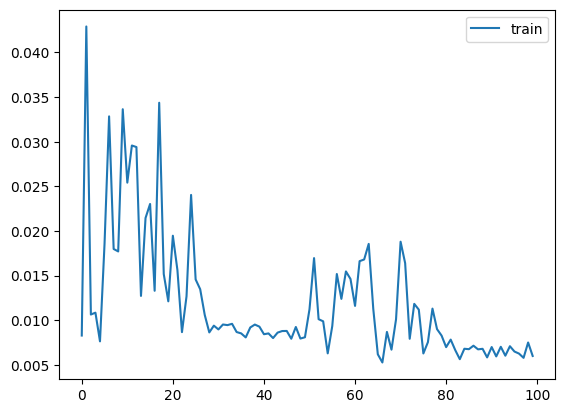

In [63]:
# Revisamos algunos parametros de ajuste del modelo!
plt.plot(history.history['loss'], label='train')
plt.legend();
plt.show()

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 184ms/step


/tmp/ipykernel_1900/2274034994.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
/tmp/ipykernel_1900/2274034994.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
/tmp/ipykernel_1900/2274034994.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.

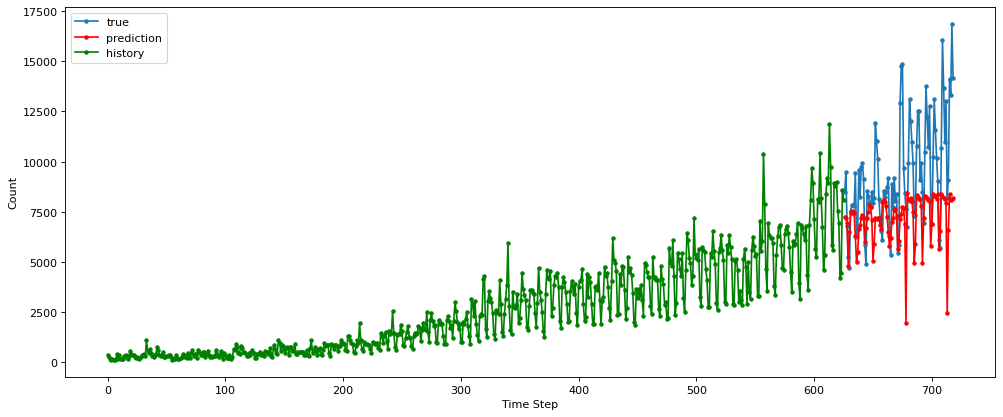

In [64]:
# Predecimos sobre la data de test!
y_pred = model_6.predict(X_test)

# Regresamos la informacion a los valores originales!
y_test = y_test*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores reales de test!
y_pred = y_pred*(train_max[0] - train_min[0]) + train_min[0]    # 100 valores pronosticados para validar!
y_train = y_train*(train_max[0] - train_min[0]) + train_min[0]  # 652 valores de entrenamiento!

# Visualizamos los resultados!
plt.figure(num=None, figsize=(15, 6), dpi=80, facecolor='w', edgecolor='k')
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_test.flatten(), marker='.', label="true")
plt.plot(np.arange(len(y_train), len(y_train) + len(y_test)), y_pred.flatten(), 'r', marker='.', label="prediction")
plt.plot(np.arange(0, len(y_train)), y_train.flatten(), 'g', marker='.', label="history")
plt.ylabel('Count')
plt.xlabel('Time Step')
plt.legend()
plt.show()